In [1]:
import pandas as pd
import numpy as np
from src.model_pipeline import ModelPipeline

# Import Data

In [2]:
df_final = pd.read_parquet("data/feature_engineering/debit/v2/df_union_debit_final.parquet")

In [3]:
df_final.set_index("Transaction Serial No", drop=True, inplace=True)

# Initiate Pipeline

In [4]:
# setup pipeline
pipeline = ModelPipeline(
    model_type="lightgbm_balanced", # using class_weight='balanced'
    random_state=42
)

Initializing ModelPipeline with model type: lightgbm
Retrieving model instance for type: lightgbm
Initializing LightGBM model...


# Splitting Train and Out-of-Sample (OOS) Data

In [5]:
split_date = "2025-05-01"

In [6]:
df_splits = pipeline.split_data_by_date(
    df=df_final,
    date_column="Transaction Datetime",
    split_date=split_date
)

Splitting data by date (pre-preprocessing)...
Train samples: 647760, Test samples: 66974
Data splitting complete.


# OverSampling Minority Class on Train Data

In [7]:
from src.imbalance_learn import ImbalancedSampler

In [8]:
# prepare data
target_col = "Confirmed"
X, y = pipeline.prepare_data(
    df=df_splits["df_train"],
    target_column=target_col,
    exclude_columns=["Debit_No","Transaction Datetime"],
    is_training=True
)

Preparing data (is_training=True)...
Starting core numeric and boolean preprocessing...
  Float columns to downcast: ['time_diff', 'TxnCount_L15M', 'TxnCount_L1H', 'TxnCount_L1D', 'TxnCount_L7D', 'TxnCount_L14D', 'TxnCount_L30D', 'TxnCount_L90D', 'TxnCount_to_MCC_L15M', 'TxnCount_to_MCC_L1H', 'TxnCount_to_MCC_L1D', 'TxnCount_to_MCC_L7D', 'TxnCount_to_MCC_L14D', 'TxnCount_to_MCC_L30D', 'TxnCount_to_MCC_L90D', 'TxnCount_to_CountryCode_L15M', 'TxnCount_to_CountryCode_L1H', 'TxnCount_to_CountryCode_L1D', 'TxnCount_to_CountryCode_L7D', 'TxnCount_to_CountryCode_L14D', 'TxnCount_to_CountryCode_L30D', 'TxnCount_to_CountryCode_L90D', 'TxnCount_to_MCC_catcode_L15M', 'TxnCount_to_MCC_catcode_L1H', 'TxnCount_to_MCC_catcode_L1D', 'TxnCount_to_MCC_catcode_L7D', 'TxnCount_to_MCC_catcode_L14D', 'TxnCount_to_MCC_catcode_L30D', 'TxnCount_to_MCC_catcode_L90D', 'TxnCount_to_MCC_cat_L15M', 'TxnCount_to_MCC_cat_L1H', 'TxnCount_to_MCC_cat_L1D', 'TxnCount_to_MCC_cat_L7D', 'TxnCount_to_MCC_cat_L14D', 'TxnCount

In [9]:
# split data
X_train, X_test, y_train, y_test = pipeline.split_data(X, y, test_size=0.3)

Splitting data into train and test sets...
Data splitting complete.


In [10]:
# OverSampling
ros_sampler = ImbalancedSampler(
    algorithm='RandomOverSampler',
    sampler_type='upsample',
    target_ratio=0.1,
    random_state=1234
)

X_train_ros, y_train_ros = ros_sampler.fit_resample(X_train, y_train)

Original dataset shape: Counter({0.0: 453118, 1.0: 314})
Resampled dataset shape using RandomOverSampler: Counter({0.0: 453118, 1.0: 45311})


# Train ML

In [11]:
# build and train
pipeline.build_pipeline()
pipeline.train(X_train_ros, y_train_ros, show_training_log=False)

Building pipeline...
Pipeline built.
Training model...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 45311, number of negative: 453118
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.369843 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 47083
[LightGBM] [Info] Number of data points in the train set: 498429, number of used features: 249
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

In [12]:
# Evaluate
test_results = pipeline.evaluate(X_test, y_test)

Evaluating model...
Accuracy: 0.9996
AUC: 0.9890
PR AUC: 0.6825
Precision: 0.9067
Recall: 0.5037

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    194193
         1.0       0.91      0.50      0.65       135

    accuracy                           1.00    194328
   macro avg       0.95      0.75      0.82    194328
weighted avg       1.00      1.00      1.00    194328



# Feature Importance

In [16]:
# Feature importance
importance_df = pipeline.get_feature_importance(X_train_ros, y_train_ros)

Getting feature importances...
  Using native feature importances.


In [17]:
pd.set_option("display.max_rows", None)
importance_df.reset_index(drop=True)

,feature,importance
0,Balance,662
1,CustomerAge,560
2,Transaction Amount,537
3,CntUnique_CardNo_by_cardAcceptor_cat_L90D,511
4,CntUnique_CardNo_by_cardAcceptor_cat_L1D,504
5,CntUnique_CardNo_by_cardAcceptor_cat_L7D,416
6,time_diff,400
7,CntUnique_CardNo_by_cardAcceptor_cat_L1H,382
8,CntUnique_CardNo_by_cardAcceptor_cat_L30D,375
9,CntUnique_CardNo_by_cardAcceptor_cat_L14D,374


In [21]:
print("Total Features:", importance_df.feature.nunique())
print("Total Non-Zero Importance Features:", importance_df[importance_df.importance > 0].feature.nunique())

Total Features: 259
Total Non-Zero Importance Features: 198


# Model Evaluation

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
def plot_confusion_matrix(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    threshold: float = 0.5
):
    y_pred = (y_prob >= threshold).astype(int)
    
    cm = confusion_matrix(y_true, y_pred)
    
    # plot using seaborn heatmap
    tn, fp, fn, tp = cm.ravel()
    labels = ["Non-Fraud", "Fraud"]
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    print(f"Recall/True Positive Rate: The model got {np.round(tp/(tp+fn)*100, 2)}% of correctly predicted fraud from all of the actual fraud transactions")
    print(f"Precision: The model got {np.round(tp/(tp+fp)*100, 2)}% of correctly predicted fraud from all transactions that predicted as fraud")
    print(f"False Positive Rate: The model got {np.round(fp/(fp+tn)*100, 2)}% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud")

In [15]:
y_prob = pipeline.pipeline.predict_proba(X_test)[:, 1]

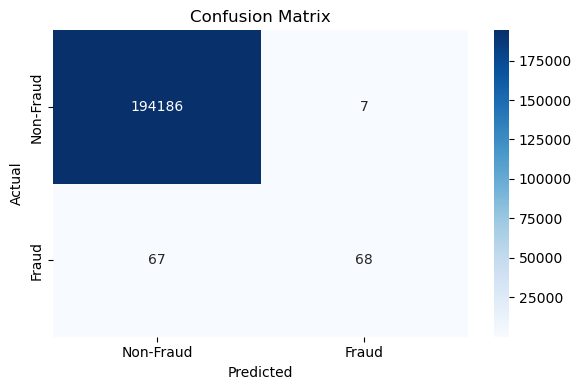

Recall/True Positive Rate: The model got 50.37% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 90.67% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 0.0% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [16]:
plot_confusion_matrix(y_test, y_prob, 0.5)

# Save Training Artifacts

In [31]:
importance_df.reset_index(drop=True).to_csv("data/result/debit_model_feature_importance_lgb_20250612.csv")

# Back-Testing with OOS Data

In [17]:
df_debit_mix = pd.read_parquet("data/base/df_debit_clean_v2.parquet")

In [18]:
trx_id_list = list(df_debit_mix[df_debit_mix.Confirmed.isin([0,1])]['Transaction Serial No'])
df_oos_new = df_splits["df_test"][df_splits["df_test"].index.isin(trx_id_list)]

In [22]:
X_oos, y_oos = pipeline.prepare_data(
    df=df_splits["df_test"],
    # df=df_oos_new,
    target_column=target_col,
    exclude_columns=["Debit_No","Transaction Datetime"],
    is_training=False # set to False for back-testing/predicting OOS data
)

Preparing data (is_training=False)...
Starting core numeric and boolean preprocessing...
  Float columns to downcast: ['time_diff', 'TxnCount_L15M', 'TxnCount_L1H', 'TxnCount_L1D', 'TxnCount_L7D', 'TxnCount_L14D', 'TxnCount_L30D', 'TxnCount_L90D', 'TxnCount_to_MCC_L15M', 'TxnCount_to_MCC_L1H', 'TxnCount_to_MCC_L1D', 'TxnCount_to_MCC_L7D', 'TxnCount_to_MCC_L14D', 'TxnCount_to_MCC_L30D', 'TxnCount_to_MCC_L90D', 'TxnCount_to_CountryCode_L15M', 'TxnCount_to_CountryCode_L1H', 'TxnCount_to_CountryCode_L1D', 'TxnCount_to_CountryCode_L7D', 'TxnCount_to_CountryCode_L14D', 'TxnCount_to_CountryCode_L30D', 'TxnCount_to_CountryCode_L90D', 'TxnCount_to_MCC_catcode_L15M', 'TxnCount_to_MCC_catcode_L1H', 'TxnCount_to_MCC_catcode_L1D', 'TxnCount_to_MCC_catcode_L7D', 'TxnCount_to_MCC_catcode_L14D', 'TxnCount_to_MCC_catcode_L30D', 'TxnCount_to_MCC_catcode_L90D', 'TxnCount_to_MCC_cat_L15M', 'TxnCount_to_MCC_cat_L1H', 'TxnCount_to_MCC_cat_L1D', 'TxnCount_to_MCC_cat_L7D', 'TxnCount_to_MCC_cat_L14D', 'TxnCoun

In [23]:
# Evaluate
oos_results = pipeline.evaluate(X_oos, y_oos)

Evaluating model...
Accuracy: 0.9993
AUC: 0.9791
PR AUC: 0.3186
Precision: 0.3793
Recall: 0.2821

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     66935
         1.0       0.38      0.28      0.32        39

    accuracy                           1.00     66974
   macro avg       0.69      0.64      0.66     66974
weighted avg       1.00      1.00      1.00     66974



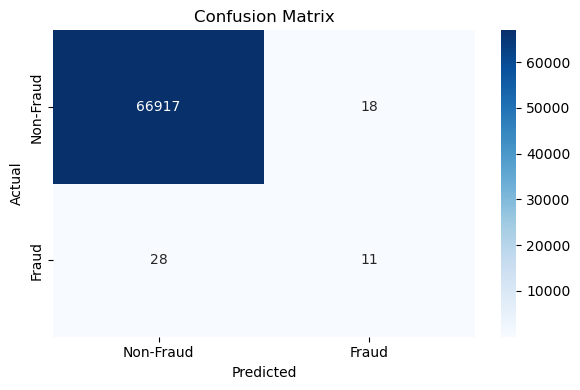

Recall/True Positive Rate: The model got 28.21% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 37.93% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 0.03% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [24]:
y_oos_prob = pipeline.pipeline.predict_proba(X_oos)[:, 1]
plot_confusion_matrix(y_oos, y_oos_prob, 0.5)

# CV Eval

In [ ]:
pipeline.build_pipeline()
cv_scores = pipeline.cross_validate(X, y, cv=5)
print("CV Scores:", cv_scores)